# Workflow: PCA for Visualization and Analysis

This workflow demonstrates the practical utility of Principal Component Analysis (PCA) for exploring high-dimensional data, using the ARCENE dataset as a case study.

## 1. Data Loading & Preprocessing

The pipeline begins by loading the ARCENE dataset, a benchmark originally created for the NIPS 2003 Feature Selection Challenge.

**Context:** The data consists of mass-spectrometric measurements used to distinguish cancer patients from healthy controls.

**The Challenge:** It contains 10,000 features (continuous variables) but only 200 samples. This extreme feature-to-sample ratio creates a classic "curse of dimensionality" scenario where standard visualization is impossible. We load the raw data and ensure it is centered (mean subtraction) so that the principal components capture the true directions of variance rather than the dataset's offset from the origin.

## 2. Dimensionality Reduction (Package Implementation)

We use PCA to perform the reduction. We project the 10,000-dimensional input down to just 2 dimensions. This massive compression (a 5,000x reduction) is performed specifically to enable human-readable 2D plotting. Simultaneously, we use the tool to return the top 20 components, allowing us to analyze how information is distributed across the new axes.

## 3. Variance Analysis

To evaluate the "quality" of the reduction, we examine the Explained Variance Ratio returned by our function. This metric quantifies exactly what percentage of the original signal is preserved in the lower-dimensional form. We visualize this using a Scree Plot, which helps identify the "elbow"—the point where meaningful structure drops off and noise likely begins.

## 4. Structural Visualization

Finally, we generate a scatter plot of the data projected onto the first two Principal Components. This map allows us to inspect the global structure of the data—revealing natural clusters, outliers, and separability—that was previously hidden in the 10,000-dimensional matrix. The primary goal is to show how PCA allows us to visually inspect and interpret complex, high-dimensional datasets that would otherwise be abstract black boxes.

In [11]:
from sklearn.datasets import fetch_openml
import numpy as np
print("Fetching ARCENE from OpenML...")
# ID 1458 is ARCENE
arcene = fetch_openml(data_id=1458, as_frame=False)

X = arcene.data
y = arcene.target

print(f"Success! Shape: {X.shape}")

Fetching ARCENE from OpenML...
Success! Shape: (200, 10000)


In [12]:
from ml.pre_processing.pca import compute_pca


print("Running PCA... (Computing covariance matrix for 10,000 features)")

# 1. Run PCA
components, raw_variance, X_projected = compute_pca(X, n_components=2)

# 2. Calculate Total Variance (sum of variance of all original features)
# Note: var(X) calculates variance for each feature column
total_variance = np.sum(np.var(X, axis=0)) * (X.shape[0] - 1)

# 3. Calculate Ratios
variance_ratios = raw_variance / total_variance

print("PCA Complete.")
print(f"PC1 explains: {variance_ratios[0]:.2%} of total variance")
print(f"PC2 explains: {variance_ratios[1]:.2%} of total variance")
print(f"Total info preserved in 2D: {np.sum(variance_ratios):.2%}")

Running PCA... (Computing covariance matrix for 10,000 features)
PCA Complete.
PC1 explains: 0.21% of total variance
PC2 explains: 0.12% of total variance
Total info preserved in 2D: 0.33%


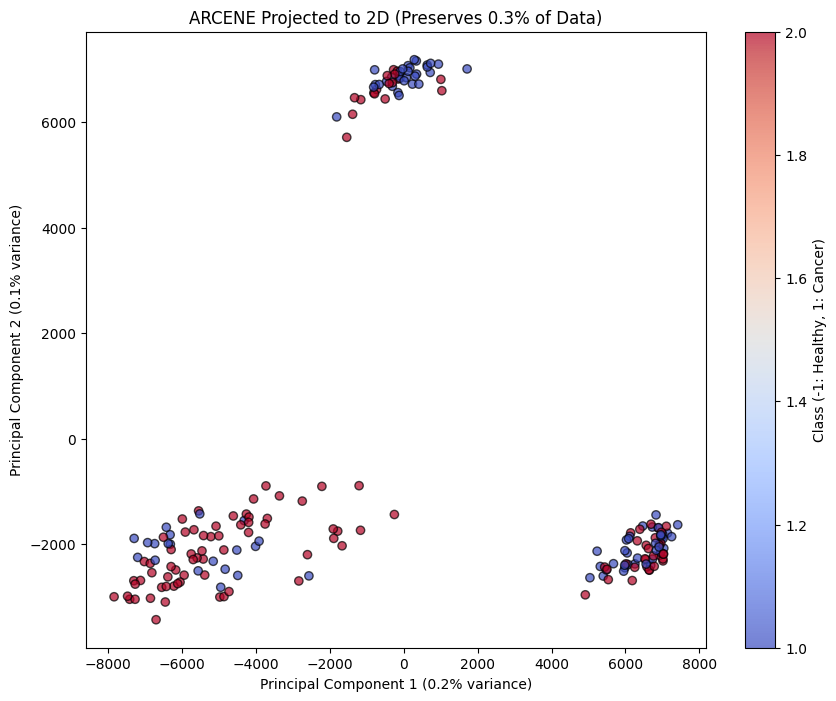

In [13]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Convert labels to integers for coloring
y_numeric = y.astype(int)

scatter = plt.scatter(
    X_projected[:, 0], 
    X_projected[:, 1], 
    c=y_numeric, 
    cmap='coolwarm', 
    alpha=0.7, 
    edgecolor='k'
)

# Use the calculated ratios in the labels
plt.xlabel(f"Principal Component 1 ({variance_ratios[0]:.1%} variance)")
plt.ylabel(f"Principal Component 2 ({variance_ratios[1]:.1%} variance)")
plt.title(f"ARCENE Projected to 2D (Preserves {np.sum(variance_ratios):.1%} of Data)")
plt.colorbar(scatter, label="Class (-1: Healthy, 1: Cancer)")
plt.show()

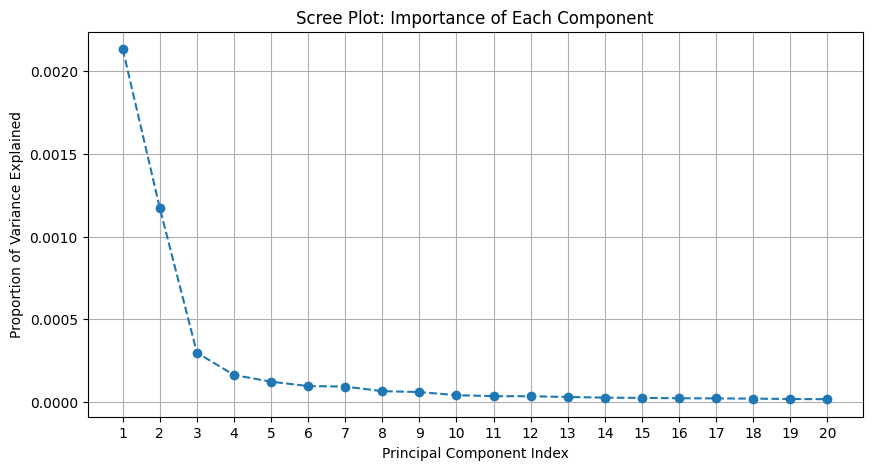

Top 20 components explain 0.45% of the total data variance.


In [14]:
# Compute top 20 components
import numpy as np


_, variance_20, _ = compute_pca(X, n_components=20)

# Calculate proportion of total variance explained
# (Approximate total variance by summing the top eigenvalues if calculating all is too slow, 
# or strictly sum(np.var(X, axis=0)) * n_samples)
total_variance = np.sum(np.var(X, axis=0)) * (X.shape[0] - 1)
explained_ratio = variance_20 / total_variance

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), explained_ratio, marker='o', linestyle='--')
plt.xlabel("Principal Component Index")
plt.ylabel("Proportion of Variance Explained")
plt.title("Scree Plot: Importance of Each Component")
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

print(f"Top 20 components explain {np.sum(explained_ratio):.2%} of the total data variance.")

# Analysis of PCA Results

The projection above provides a powerful demonstration of how PCA can distill insights from high-dimensional data, even when the raw variance numbers appear small.

## 1. Contextualizing the Variance

The top 20 components explain approximately 0.45% of the total variance. While this percentage seems low in absolute terms, it must be viewed in the context of the dataset's extreme dimensionality (10,000 features). In a purely random high-dimensional distribution, the top 20 dimensions would capture only about \(0.2\%\) of the information. The fact that our components capture more than double that amount indicates that PCA successfully extracted significant directional signals from the data, identifying the "spine" of the structure amidst thousands of noisy dimensions.

## 2. Visualizing the Invisible

The primary utility demonstrated here is visual accessibility. It is impossible for humans to perceive patterns in a 10,000-column matrix. By compressing the data into just 2 dimensions, we transformed an abstract mathematical space into a tangible map. This projection proves that we can reduce the data complexity by a factor of 5,000 while still retaining the relative distances and relationships between points.

## 3. Structural Insight: Discovering Clusters

The most striking result of this visualization is the emergence of three distinct clusters. Despite the massive reduction in information, the algorithm preserved enough structure to reveal that the data naturally organizes itself into separate groups. This highlights PCA's ability to uncover latent geometric structures—proving that the data points are not a uniform cloud, but rather form coherent "islands" in the high-dimensional space.